In [43]:
import numpy as np
import numpy.matlib
import queue as queue
from scipy.optimize import brenth,brentq,newton,fsolve,fminbound
import time
import multiprocessing
import networkx as nx
import pulp
from IPython.core.display import clear_output


In [44]:
#computing kl divergence:
def div(Ps,Qs):
    return np.sum(Ps*np.log(Ps/Qs))

In [45]:
#computing the minimum of divergence using Han "Hypothesis testing with multiterminal data compression"
def arg_min_const_marg(Px,Py,Qxy,tol=1e-6):
    terr=tol+0.1
    s_x=Px.shape
    s_y=Py.shape
    g_x=np.random.random(s_x)
    g_y=np.random.random(s_y)
    err_x=np.zeros(s_y)
    err_y=np.zeros(s_x)
    m_xx=0.0
    m_yy=0.0
    while terr > tol:
        g_x_p=Px/(np.dot(Qxy,g_y))
        g_y_p=Py/(np.dot(Qxy.T,g_x))
        err_y=abs(g_x-g_x_p)
        err_x=abs(g_y-g_y_p)
        terr=np.sum(err_x)+np.sum(err_y)
        m_x=np.tile(g_x_p.reshape(s_x[0],1),(1,s_y[0]))
        m_y=np.tile(g_y_p.reshape(1,s_y[0]),(s_x[0],1))
        g_x=g_x_p
        g_y=g_y_p        
        m=np.sum(m_x*m_y*Qxy)
        g_x/=m
    g_x=np.tile(g_x_p.reshape(s_x[0],1),(1,s_y[0]))
    g_y=np.tile(g_y_p.reshape(1,s_y[0]),(s_x[0],1))
    return g_y*g_x*Qxy

In [46]:
#A function to compute the exponent for a partition
def exp_region(parts,X_parts,curr_D,K):
    theta=[]
    for k in range(0,K):
        t=1000.0
        for (X_part,part) in zip(X_parts,parts):
            for m in part:
                for p in X_part:
                    if not m==k:
                        if curr_D[p,m,k]< t:                            
                            t=curr_D[p,m,k]
        theta.append(t)
    return np.array(theta)


In [47]:
#function to generate partition of hypothesis
def partition(collection):
    if len(collection) == 1:
        yield [ collection ]
        return

    first = collection[0]
    for smaller in partition(collection[1:]):
        # insert `first` in each of the subpartition's subsets
        for n, subset in enumerate(smaller):
            yield smaller[:n] + [[ first ] + subset]  + smaller[n+1:]
        # put `first` in its own subset 
        yield [ [ first ] ] + smaller
#finding all the exponent for all the possible partition
def get_exponent(W,M,K,D,R):
    curr_D=np.zeros(D.shape)
    exp=[]
    for part in partition([p for p in range(0,M)]):
        if len(part)<=W:
            part+=[[] for p in range(0,W-len(part))]
            print( part)
            for r in range(0,len(R)):
                curr_D[:]=np.tile(np.array(R[r]).reshape((1,1,K)),(N+M,M,1))+D
                X_parts=[[] for w in range (0,W)]
                for l in np.arange(0,N):
                    cmp_array=exp_X_reg(part,l,curr_D,K)
                    i_x=np.argmax(np.array(cmp_array))
                    X_parts[i_x].append(l)
                new_X_parts=[x_part+[p+N for p in pa] for (x_part,pa) in zip(X_parts,part)]
                X_parts=new_X_parts 
                theta=exp_region(part, X_parts, D, K)
                exp.append(theta)
     
    return exp


In [48]:
#Size of the message
W=2
#Number of hypothesus
M=3
#number of detector
K=2
#matrix representing the pmfs.
Pxy_m=np.transpose([ [  [0.30,0.23],[0.27,0.20]],[  [0.14,0.29],[0.31,0.26]] ,[  [0.52,0.18],[0.23,0.07]]     ],(1,2,0))
#Marginals
Px_m=Pxy_m.sum((1))
Py_m=Pxy_m.sum((0))
D=[]


#Add the set of a "large" enought subset of the pmf of X  
Px0=[[p,1.0-p] for p in np.arange(1e-8,1,1e-3)]
Px0=np.array(Px0).T
N=Px0.shape[1]
Px=np.concatenate((Px0,Px_m),1)
#computing the possible minimum of divergence with fixed marginals
D=[]
for k in np.arange(0,M+N):
    for l in np.arange(0,M):
            for n in np.arange(0,K):
                D.append(div(arg_min_const_marg(Px[:,k],Py_m[:,l],Pxy_m[:,:,n],1e-10),Pxy_m[:,:,n]))
D1=np.array(D).reshape(N+M,M,K)

In [49]:
#finding all the exponents
exp_1=get_exponent(W,M,K,D1,[np.array([x,0.0]) for x in np.arange(-0.080,0.080,1e-3)])


[[0, 1, 2], []]
[[0], [1, 2]]
[[0, 1], [2]]
[[1], [0, 2]]


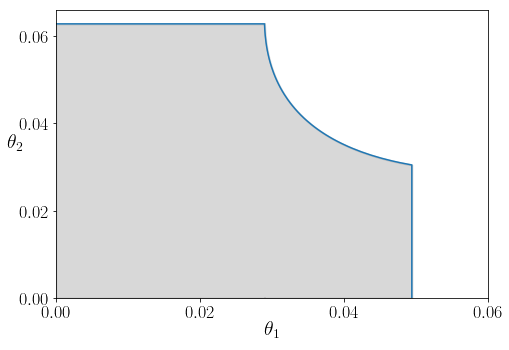

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from shapely.geometry import MultiPoint
#We throw away all the point inside the region(i.e not on the boundary)
def prepare_data(exp):
    exp_0=np.max(np.array(exp)[:,0])
    exp_1=np.max(np.array(exp)[:,1])
    final_reg=[]
    for p in exp:
        is_ok=True
        for q in exp:
            if np.all(q>p):
                is_ok=False
        if is_ok:
            final_reg.append(p)
    final_reg=np.array(final_reg+[[exp_0,0.0],[0.0,exp_1]])
    index=np.argsort(final_reg[:,1] )
    final_reg=final_reg[index,:]
    return final_reg
f1=prepare_data(exp_1)
#ploting the boundary
fig = plt.figure()
ax = fig.add_axes([1,1,1,1])


plt.rc('text', usetex=True)
ax.set_xlabel(r"$\theta_1$",fontsize=20,)
ax.set_ylabel(r"$\theta_2$",fontsize=20,rotation=0)
ax.plot(f1[:,0] ,f1[:,1],'-',)
ax.fill_between(f1[:,0] ,f1[:,1],color='grey',linewidth=2.0, alpha='0.3')
#ax.plot(f2[:,0] ,f2[:,1],'-')

ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
ax.set_xticks([p for p in np.arange(0.0,0.08,2e-2)])
ax.set_yticks([p for p in np.arange(0.0,0.08,2e-2)])

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(18) 
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(18) 
    # specify integer or one of preset strings, e.g.
    #tick.label.set_fontsize('x-small') 

fig.savefig('test.png', bbox_inches='tight',dpi=120)